# Simulation-Derived Score With Analytical Covariance

This notebook isolates one question: if the covariance is known analytically, can we replace the analytical score/Jacobian with a score estimated from simulations and still recover the same compressed posterior?

The validation compares four contours:

1. strict HMC benchmark on the full analytical data vector;
2. score-compressed Student-t likelihood using the **analytical score** and analytical covariance;
3. score-compressed Student-t likelihood using a **simulation-estimated finite-difference score** and analytical covariance;
4. the best saved analytical NPE/SNPE contour for comparison.

The finite-difference score section is intentionally written as a replaceable simulation interface: later the `simulate_statistic(theta, seed)` function can be swapped for pasted-map/catalog simulations and higher-order statistic measurements.

## Imports and Configuration

`%matplotlib inline` is intentionally before GetDist plotter calls.

In [1]:
%matplotlib inline

import json
import os
import pathlib
import sys
import time
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

from getdist import MCSamples, plots, chains

chains.print_load_details = False

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax.numpy as jnp

CWD = pathlib.Path.cwd().resolve()
if (CWD / "notebooks" / "SBI_validate").exists():
    REPO_ROOT = CWD
    SBI_DIR = CWD / "notebooks" / "SBI_validate"
elif CWD.name == "SBI_validate":
    SBI_DIR = CWD
    REPO_ROOT = CWD.parents[1]
else:
    for parent in (CWD, *CWD.parents):
        candidate = parent / "notebooks" / "SBI_validate"
        if candidate.exists():
            REPO_ROOT = parent
            SBI_DIR = candidate
            break
    else:
        raise RuntimeError("Could not locate notebooks/SBI_validate")

if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from theory_sbi_utils import (
    DEFAULT_FIDUCIAL_PATH,
    THEORY_SBI_DIR,
    default_parameter_specs,
    fiducial_theta,
    make_inference_theory_vector_function,
    prior_bounds,
    selected_product_arrays,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "legend.frameon": False,
})

FIDUCIAL_PATH = pathlib.Path(DEFAULT_FIDUCIAL_PATH).resolve()
HMC_DIR = pathlib.Path(THEORY_SBI_DIR) / "joint_gg_gy_gtau_gkappa_linearized_hmc_strict"
NPE_SEARCH_ROOT = pathlib.Path(THEORY_SBI_DIR)
OUTPUT_DIR = pathlib.Path(THEORY_SBI_DIR) / "simulation_score_analytic_covariance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROBES = ("gg", "gy", "gtau", "gkappa")
ELL_MIN = None
ELL_MAX = None
THEORY_BACKEND = "linearized"

PARAM_SPECS = default_parameter_specs()
PARAM_NAMES = tuple(spec.name for spec in PARAM_SPECS)
PARAM_LABELS = tuple(spec.label for spec in PARAM_SPECS)
THETA0 = fiducial_theta(PARAM_SPECS)
PRIOR_MIN, PRIOR_MAX = prior_bounds(PARAM_SPECS)
NPARAM = len(THETA0)

# Score simulations. Common random numbers cancel additive mock-noise in the finite difference,
# matching the strategy one would use with paired simulations when possible.
N_FD_PAIRS = 32
FD_DELTAS = 0.05 * (PRIOR_MAX - PRIOR_MIN)
USE_COMMON_RANDOM_NUMBERS = True
BASE_SEED = 20260527

# With exact analytical covariance the Gaussian compressed likelihood is the strict choice.
# We keep the Student-t form with this effective covariance simulation count to match the
# previous compressed-likelihood comparisons. Set very large for a Gaussian limit.
STUDENT_T_NCOV_EFFECTIVE = 256
GRID_SIZE = 600
POSTERIOR_SAMPLES = 50_000

GETDIST_SETTINGS = {
    "ignore_rows": 0,
    "smooth_scale_1D": 0.35,
    "smooth_scale_2D": 0.45,
    "boundary_correction_order": 1,
}


def display_table(rows: list[dict[str, Any]], columns: list[str] | None = None):
    if pd is not None:
        frame = pd.DataFrame(rows)
        if columns is not None and len(frame):
            frame = frame[[c for c in columns if c in frame.columns]]
        display(frame)
    else:
        print(json.dumps(rows, indent=2, default=str))

print(f"Repository root: {REPO_ROOT}")
print(f"Fiducial product: {FIDUCIAL_PATH}")
print(f"HMC benchmark: {HMC_DIR}")
print(f"NPE/SNPE search root: {NPE_SEARCH_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Repository root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX
Fiducial product: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/fiducial_thetaej2_nuejm_minus0p1.npz
HMC benchmark: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/joint_gg_gy_gtau_gkappa_linearized_hmc_strict
NPE/SNPE search root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi
Output directory: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/simulation_score_analytic_covariance


## Load Analytical Data Vector and Covariance

The covariance is fixed to the analytical covariance from the fiducial product. The only quantity we vary in this notebook is how the score/Jacobian used for compression is obtained.

In [2]:
selected = selected_product_arrays(FIDUCIAL_PATH, probes=PROBES, ell_min=ELL_MIN, ell_max=ELL_MAX)
selection = selected["selection"]
obs = np.asarray(selected["data_vector"], dtype=float)
fiducial_mean_statistic = obs.copy()
observed_statistic = obs.copy()
cov = np.asarray(selected["cov"], dtype=float)
precision = np.asarray(selected["precision"], dtype=float)
chol = np.asarray(selected["chol"], dtype=float)
ndata = len(obs)

vector_fn, theory_info = make_inference_theory_vector_function(
    PARAM_SPECS,
    selection,
    fiducial_vector=obs,
    backend=THEORY_BACKEND,
    fiducial_offset=True,
    jit_compile=True,
)
analytic_jac = np.asarray(theory_info["jacobian"], dtype=float)

summary_rows = [
    {"quantity": "statistic dimension", "value": ndata},
    {"quantity": "probes", "value": ", ".join(PROBES)},
    {"quantity": "fiducial theta", "value": THETA0.tolist()},
    {"quantity": "prior min", "value": PRIOR_MIN.tolist()},
    {"quantity": "prior max", "value": PRIOR_MAX.tolist()},
    {"quantity": "FD pairs per parameter", "value": N_FD_PAIRS},
    {"quantity": "FD deltas", "value": FD_DELTAS.tolist()},
    {"quantity": "Student-t effective Ncov", "value": STUDENT_T_NCOV_EFFECTIVE},
]
display_table(summary_rows)

[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


,quantity,value
0,statistic dimension,80
1,probes,"gg, gy, gtau, gkappa"
2,fiducial theta,"[2.0, -0.1]"
3,prior min,"[0.5, -1.0]"
4,prior max,"[4.0, 0.0]"
5,FD pairs per parameter,32
6,FD deltas,"[0.17500000000000002, 0.05]"
7,Student-t effective Ncov,256


## Replaceable Simulation Interface for Score Estimation

Here `simulate_statistic(theta, seed)` is an analytical stand-in for “run a simulation, add noise, and measure summary statistics.” The compression code only sees its returned vector. Later this is the function to replace with pasted-map/catalog simulations and higher-order statistic measurements.

In [3]:
def hidden_mean_statistic(theta: np.ndarray) -> np.ndarray:
    return np.asarray(vector_fn(jnp.asarray(theta, dtype=jnp.float64)), dtype=float)


def simulate_statistic(theta: np.ndarray, seed: int, *, add_noise: bool = True) -> np.ndarray:
    theta = np.asarray(theta, dtype=float)
    mean = hidden_mean_statistic(theta)
    if not add_noise:
        return mean
    rng = np.random.default_rng(int(seed))
    return mean + chol @ rng.normal(size=ndata)


def estimate_score_from_simulations(
    theta0: np.ndarray,
    deltas: np.ndarray,
    n_pairs: int,
    seed: int,
    *,
    common_random_numbers: bool = True,
) -> tuple[np.ndarray, dict[str, Any]]:
    rng = np.random.default_rng(seed)
    theta0 = np.asarray(theta0, dtype=float)
    deltas = np.asarray(deltas, dtype=float)
    jac = np.zeros((ndata, len(theta0)), dtype=float)
    rows = []

    for ip, delta in enumerate(deltas):
        theta_plus = theta0.copy()
        theta_minus = theta0.copy()
        theta_plus[ip] += delta
        theta_minus[ip] -= delta
        if theta_plus[ip] > PRIOR_MAX[ip] or theta_minus[ip] < PRIOR_MIN[ip]:
            raise ValueError(f"FD step for {PARAM_NAMES[ip]} leaves prior")

        derivs = []
        for _ in range(int(n_pairs)):
            seed_plus = int(rng.integers(0, 2**31 - 1))
            seed_minus = seed_plus if common_random_numbers else int(rng.integers(0, 2**31 - 1))
            plus = simulate_statistic(theta_plus, seed_plus, add_noise=True)
            minus = simulate_statistic(theta_minus, seed_minus, add_noise=True)
            derivs.append((plus - minus) / (2.0 * delta))
        derivs = np.asarray(derivs, dtype=float)
        jac[:, ip] = derivs.mean(axis=0)
        rows.append({
            "parameter": PARAM_NAMES[ip],
            "delta": float(delta),
            "pairs": int(n_pairs),
            "common_random_numbers": bool(common_random_numbers),
            "median_abs_derivative_scatter": float(np.median(np.std(derivs, axis=0, ddof=1))) if len(derivs) > 1 else 0.0,
        })

    return jac, {"rows": rows}

sim_score_jac, sim_score_info = estimate_score_from_simulations(
    THETA0,
    FD_DELTAS,
    N_FD_PAIRS,
    seed=BASE_SEED,
    common_random_numbers=USE_COMMON_RANDOM_NUMBERS,
)

display_table(sim_score_info["rows"])
print("Relative score/Jacobian error vs hidden analytical score:", np.linalg.norm(sim_score_jac - analytic_jac) / np.linalg.norm(analytic_jac))

,parameter,delta,pairs,common_random_numbers,median_abs_derivative_scatter
0,theta_ej_0,0.175,32,True,7.929578e-27
1,nu_theta_ej_M,0.050,32,True,0.000000e+00


Relative score/Jacobian error vs hidden analytical score: 2.0725056991373625e-12


## Score Compression With Analytical Covariance

For a Jacobian $J$ and analytical precision matrix $P=C^{-1}$, the score-compressed summary in parameter units is

$$t(x) = \theta_0 + (J^T P J)^{-1}J^TP[x-\mu_0].$$

The compressed covariance is computed from the analytical raw covariance, $C_t = B C B^T$. The posterior is then evaluated with a Student-t likelihood using the same compressed covariance and an effective covariance simulation count for comparison to the earlier Student-t compressed-likelihood notebooks.

In [4]:
def stable_inverse(covariance: np.ndarray, floor_frac: float = 1.0e-14) -> tuple[np.ndarray, float]:
    covariance = 0.5 * (np.asarray(covariance, dtype=float) + np.asarray(covariance, dtype=float).T)
    evals, evecs = np.linalg.eigh(covariance)
    floor = floor_frac * max(float(np.max(evals)), 1.0e-300)
    clipped = np.clip(evals, floor, None)
    inv = (evecs / clipped[None, :]) @ evecs.T
    logdet = float(np.sum(np.log(clipped)))
    return 0.5 * (inv + inv.T), logdet


def build_compressed_model(jac: np.ndarray, name: str) -> dict[str, Any]:
    jac = np.asarray(jac, dtype=float)
    fisher = jac.T @ precision @ jac
    fisher = 0.5 * (fisher + fisher.T)
    fisher_inv = np.linalg.pinv(fisher)
    compression = fisher_inv @ jac.T @ precision
    compressed_obs = THETA0 + compression @ (observed_statistic - fiducial_mean_statistic)
    compressed_cov = compression @ cov @ compression.T
    compressed_cov = 0.5 * (compressed_cov + compressed_cov.T)
    response = compression @ jac
    return {
        "name": name,
        "jacobian": jac,
        "fisher": fisher,
        "fisher_inv": fisher_inv,
        "compression": compression,
        "compressed_obs": compressed_obs,
        "compressed_cov": compressed_cov,
        "response": response,
    }

analytic_model = build_compressed_model(analytic_jac, "analytic_score")
sim_score_model = build_compressed_model(sim_score_jac, "simulation_score")

model_rows = []
for model in (analytic_model, sim_score_model):
    eig = np.linalg.eigvalsh(model["compressed_cov"])
    model_rows.append({
        "model": model["name"],
        "max_abs_response_minus_I": float(np.max(np.abs(model["response"] - np.eye(NPARAM)))),
        "cov_theta_std": np.sqrt(np.diag(model["compressed_cov"])).tolist(),
        "cov_min_eig": float(np.min(eig)),
        "cov_max_eig": float(np.max(eig)),
    })
display_table(model_rows)

,model,max_abs_response_minus_I,cov_theta_std,cov_min_eig,cov_max_eig
0,analytic_score,1.741940e-13,"[0.30315303225712537, 0.04563826102806088]",0.000008,0.093976
1,simulation_score,8.015810e-13,"[0.30315303225727, 0.04563826102808254]",0.000008,0.093976


## Compressed Student-t Posteriors

Because the observed vector is the fiducial analytical data vector, the compressed observed summary is exactly the fiducial parameter vector for both compression choices. Any difference in the posteriors comes from the score used to build the compression and compressed covariance.

In [5]:
def grid_student_t_posterior(model: dict[str, Any], *, ngrid: int = GRID_SIZE, nsim: int = STUDENT_T_NCOV_EFFECTIVE) -> dict[str, Any]:
    theta0_grid = np.linspace(PRIOR_MIN[0], PRIOR_MAX[0], int(ngrid))
    theta1_grid = np.linspace(PRIOR_MIN[1], PRIOR_MAX[1], int(ngrid))
    g0, g1 = np.meshgrid(theta0_grid, theta1_grid, indexing="ij")
    theta_grid = np.stack([g0, g1], axis=-1)
    resid = model["compressed_obs"][None, None, :] - theta_grid
    inv_cov, logdet = stable_inverse(model["compressed_cov"])
    chi2 = np.einsum("...i,ij,...j->...", resid, inv_cov, resid)
    loglike = -0.5 * logdet - 0.5 * float(nsim) * np.log1p(chi2 / max(float(nsim - 1), 1.0))
    logw = loglike - np.max(loglike)
    weight = np.exp(logw)
    weight /= np.sum(weight)
    mean = np.array([np.sum(weight * g0), np.sum(weight * g1)])
    cov00 = np.sum(weight * (g0 - mean[0]) ** 2)
    cov11 = np.sum(weight * (g1 - mean[1]) ** 2)
    cov01 = np.sum(weight * (g0 - mean[0]) * (g1 - mean[1]))
    return {
        "theta0_grid": theta0_grid,
        "theta1_grid": theta1_grid,
        "weight": weight,
        "mean": mean,
        "cov": np.array([[cov00, cov01], [cov01, cov11]]),
    }


def sample_grid(grid: dict[str, Any], nsamples: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    w = np.ravel(grid["weight"])
    choice = rng.choice(w.size, size=int(nsamples), replace=True, p=w)
    i0, i1 = np.unravel_index(choice, grid["weight"].shape)
    return np.column_stack([grid["theta0_grid"][i0], grid["theta1_grid"][i1]])

analytic_grid = grid_student_t_posterior(analytic_model)
sim_score_grid = grid_student_t_posterior(sim_score_model)
analytic_score_samples = sample_grid(analytic_grid, POSTERIOR_SAMPLES, BASE_SEED + 101)
sim_score_samples = sample_grid(sim_score_grid, POSTERIOR_SAMPLES, BASE_SEED + 202)

np.savez_compressed(
    OUTPUT_DIR / "simulation_score_analytic_covariance_samples.npz",
    analytic_score_samples=analytic_score_samples,
    simulation_score_samples=sim_score_samples,
    theta_fiducial=THETA0,
    prior_min=PRIOR_MIN,
    prior_max=PRIOR_MAX,
    analytic_jacobian=analytic_jac,
    simulation_score_jacobian=sim_score_jac,
    analytic_compressed_cov=analytic_model["compressed_cov"],
    simulation_score_compressed_cov=sim_score_model["compressed_cov"],
    student_t_ncov_effective=np.asarray(STUDENT_T_NCOV_EFFECTIVE),
)

print("Saved compressed posterior samples to", OUTPUT_DIR / "simulation_score_analytic_covariance_samples.npz")

Saved compressed posterior samples to /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/simulation_score_analytic_covariance/simulation_score_analytic_covariance_samples.npz


## Load HMC and Select the Best NPE/SNPE Sample

The NPE comparison is selected from saved analytical SNPE outputs in this folder. Candidate runs must match the fiducial product, backend, fiducial-offset correction, and score-compression settings. The chosen run minimizes a simple HMC-agreement score built from mean shift, geometric marginal-width ratio, and posterior-area ratio.

In [6]:
def load_hmc_samples(path: pathlib.Path) -> np.ndarray:
    z = np.load(path / "hmc_samples.npz", allow_pickle=True)
    return np.column_stack([np.asarray(z[f"samples_{name}"], dtype=float) for name in PARAM_NAMES])


def load_sbi_samples(path: pathlib.Path) -> tuple[np.ndarray, dict[str, Any]]:
    z = np.load(path / "sbi_posterior_samples.npz", allow_pickle=True)
    diagnostics = json.loads((path / "sbi_diagnostics.json").read_text())
    return np.asarray(z["samples"], dtype=float), diagnostics


def is_joint_npe_candidate(path: pathlib.Path, diagnostics: dict[str, Any]) -> bool:
    if diagnostics.get("density_estimator") not in {"mdn", "nsf"}:
        return False
    if diagnostics.get("summary_compression") != "score":
        return False
    if diagnostics.get("theory_backend") != THEORY_BACKEND:
        return False
    if not bool(diagnostics.get("fiducial_offset_correction", False)):
        return False
    try:
        if pathlib.Path(diagnostics.get("fiducial_path", "")).resolve() != FIDUCIAL_PATH:
            return False
    except Exception:
        return False
    rel = str(path.relative_to(NPE_SEARCH_ROOT))
    return rel.startswith("joint_gg_gy_gtau_gkappa") or rel.startswith("analytical_sbi_active_learning_lowbudget/snpe_")


def npe_agreement_metrics(samples: np.ndarray) -> dict[str, float]:
    mean = samples.mean(axis=0)
    sample_cov = np.cov(samples.T, ddof=1)
    std = np.sqrt(np.diag(sample_cov))
    delta = mean - hmc_mean
    mean_shift = float(np.sqrt(delta @ hmc_inv_cov @ delta))
    width_ratio = float(np.exp(np.mean(np.log(std / hmc_std))))
    area_ratio = float(np.sqrt(max(np.linalg.det(sample_cov), 0.0) / max(np.linalg.det(hmc_cov), 1.0e-300)))
    score = float(mean_shift + abs(np.log(width_ratio)) + abs(np.log(area_ratio)))
    return {
        "npe_selection_score": score,
        "mean_shift_hmc_sigma": mean_shift,
        "geom_width_ratio": width_ratio,
        "area_ratio": area_ratio,
    }


def find_best_npe_candidate() -> dict[str, Any]:
    rows = []
    for sample_path in sorted(NPE_SEARCH_ROOT.rglob("sbi_posterior_samples.npz")):
        path = sample_path.parent
        diag_path = path / "sbi_diagnostics.json"
        if not diag_path.exists():
            continue
        try:
            samples, diagnostics = load_sbi_samples(path)
            if samples.ndim != 2 or samples.shape[1] != NPARAM:
                continue
            if not is_joint_npe_candidate(path, diagnostics):
                continue
            metrics = npe_agreement_metrics(samples)
        except Exception as exc:
            rows.append({"path": str(path.relative_to(NPE_SEARCH_ROOT)), "status": f"failed: {exc}"})
            continue
        rows.append({
            "path": str(path.relative_to(NPE_SEARCH_ROOT)),
            "status": "candidate",
            "density_estimator": diagnostics.get("density_estimator"),
            "parameter_transform": diagnostics.get("parameter_transform"),
            "simulations_per_round": diagnostics.get("simulations_per_round"),
            "samples": int(len(samples)),
            **metrics,
            "_samples": samples,
            "_diagnostics": diagnostics,
            "_path": path,
        })
    candidates = [row for row in rows if row.get("status") == "candidate"]
    if not candidates:
        raise RuntimeError("No valid joint NPE/SNPE candidate found")
    candidates = sorted(candidates, key=lambda row: row["npe_selection_score"])
    display_rows = [{k: v for k, v in row.items() if not k.startswith("_")} for row in candidates[:8]]
    display_table(display_rows)
    return candidates[0]

hmc_samples = load_hmc_samples(HMC_DIR)
hmc_mean = hmc_samples.mean(axis=0)
hmc_cov = np.cov(hmc_samples.T, ddof=1)
hmc_std = np.sqrt(np.diag(hmc_cov))
hmc_inv_cov = np.linalg.pinv(hmc_cov)
hmc_evals, hmc_evecs = np.linalg.eigh(hmc_cov)
order = np.argsort(hmc_evals)[::-1]
hmc_evals = hmc_evals[order]
hmc_evecs = hmc_evecs[:, order]
hmc_dir_widths = np.sqrt(hmc_evals)

best_npe = find_best_npe_candidate()
npe_samples = best_npe["_samples"]
npe_diag = best_npe["_diagnostics"]
best_npe_dir = best_npe["_path"]
best_npe_label = f"Best NPE / {str(npe_diag.get('density_estimator', 'npe')).upper()}"

display_table([
    {"run": "HMC", "samples": len(hmc_samples), "mean": hmc_samples.mean(axis=0).tolist(), "std": hmc_samples.std(axis=0).tolist()},
    {"run": best_npe_label, "path": str(best_npe_dir.relative_to(NPE_SEARCH_ROOT)), "samples": len(npe_samples), "mean": npe_samples.mean(axis=0).tolist(), "std": npe_samples.std(axis=0).tolist(), "metadata": {k: npe_diag.get(k) for k in ("density_estimator", "parameter_transform", "simulations_per_round")}},
])

,path,status,density_estimator,parameter_transform,simulations_per_round,samples,npe_selection_score,mean_shift_hmc_sigma,geom_width_ratio,area_ratio
0,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5,candidate,mdn,fisher,"[4096, 4096, 8192]",30000,0.320119,0.105433,1.056019,1.173722
1,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5_2x,candidate,mdn,fisher,"[8192, 8192, 16384]",30000,0.363077,0.028954,1.049872,1.330368
2,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn1...,candidate,mdn,fisher,"[512, 512, 1024]",30000,0.408974,0.094915,0.921673,1.261744
3,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn1...,candidate,mdn,fisher,"[1024, 1024, 2048]",30000,0.419703,0.152067,0.971670,1.269849
4,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5...,candidate,mdn,fisher,"[2048, 2048, 4096]",30000,0.529301,0.209085,1.032818,1.333657
5,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5...,candidate,mdn,fisher,"[512, 512, 512, 512, 512, 512, 512, 512]",30000,0.562905,0.119379,0.995076,1.550518
6,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5...,candidate,mdn,fisher,"[1024, 1024, 2048]",30000,0.603918,0.079779,1.026899,1.644763
7,joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5...,candidate,mdn,fisher,"[512, 512, 1024]",30000,0.711581,0.208086,0.995837,1.647605


,run,samples,mean,std,path,metadata
0,HMC,24000,"[1.9899896024513806, -0.10149144675603657]","[0.2876941819137636, 0.04331621360751896]",NaN,NaN
1,Best NPE / MDN,30000,"[1.9807284288806504, -0.10258946477284718]","[0.30402605141700456, 0.04571072097710009]",joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5,"{'density_estimator': 'mdn', 'parameter_transf..."


## Full Triangle Plot: Four-Contour Comparison

This is the main validation plot. HMC is the filled gray benchmark. The analytical-score and simulation-score compressed posteriors should agree if the finite-difference score is estimated well. The NPE/SNPE contour is included as a neural posterior comparison.

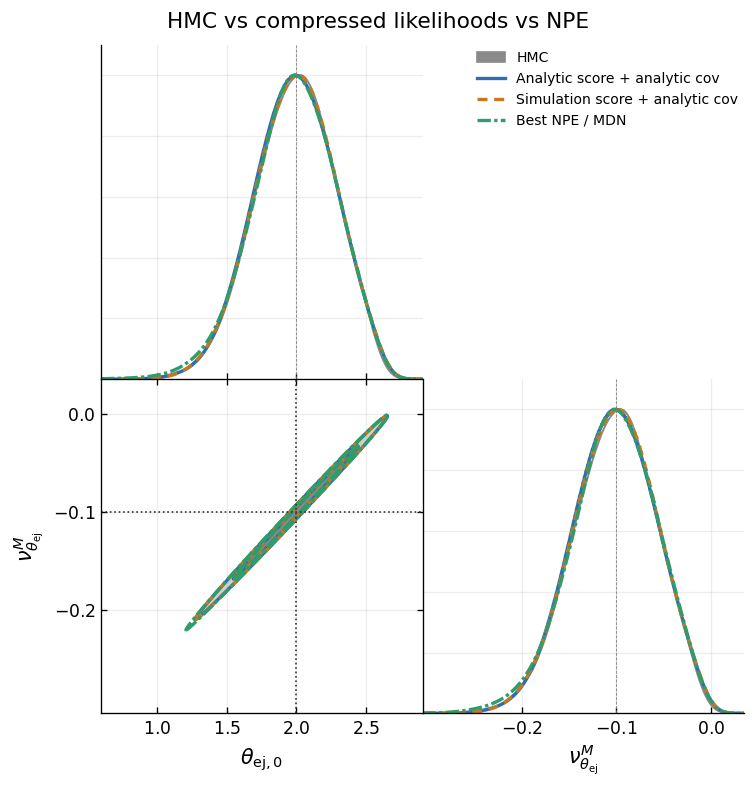

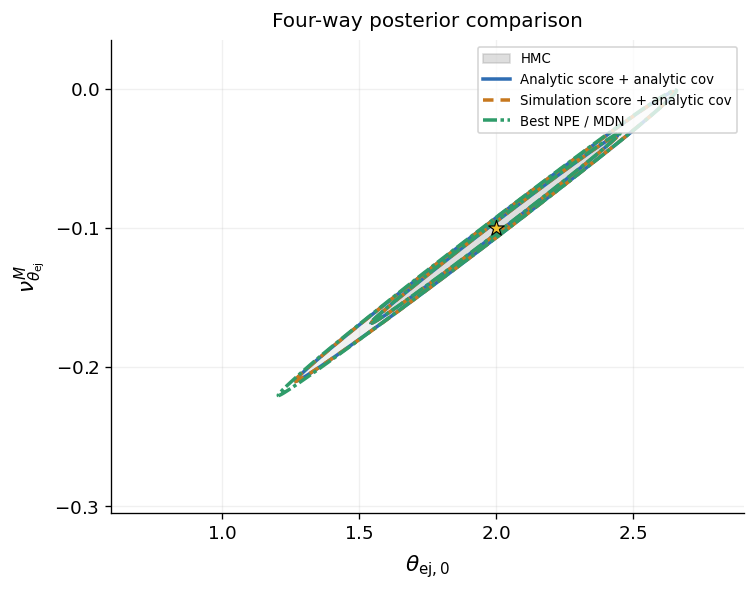

In [10]:
%matplotlib inline

def make_gd(samples: np.ndarray, label: str) -> MCSamples:
    return MCSamples(
        samples=np.asarray(samples, dtype=float),
        names=["thetaej0", "nuejM"],
        labels=[r"\theta_{\rm ej,0}", r"\nu^M_{\theta_{\rm ej}}"],
        label=label,
        settings={
            "ignore_rows": 0,
            "smooth_scale_1D": 0.35,
            "smooth_scale_2D": 0.45,
            "boundary_correction_order": 1,
        },
    )


def style_plotter(g):
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 13
    g.settings.legend_fontsize = 9
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.28
    g.settings.linewidth_contour = 1.6
    return g

roots = [
    make_gd(hmc_samples, "HMC"),
    make_gd(analytic_score_samples, "Analytic score + analytic cov"),
    make_gd(sim_score_samples, "Simulation score + analytic cov"),
    make_gd(npe_samples, best_npe_label),
]
labels = [root.label for root in roots]
colors = ["#8a8a8a", "#2f6db3", "#c7781e", "#2f9c6a"]

g = style_plotter(plots.get_subplot_plotter(width_inch=6.4))
g.triangle_plot(
    roots,
    params=["thetaej0", "nuejM"],
    filled=[True, False, False, False],
    contour_colors=colors,
    contour_lws=[1.2, 2.0, 2.0, 2.0],
    contour_ls=["-", "-", "--", "-."],
    legend_labels=labels,
    markers={"thetaej0": THETA0[0], "nuejM": THETA0[1]},
    marker_args={"color": "#333333", "ls": ":", "lw": 1.0},
)
g.fig.suptitle("HMC vs compressed likelihoods vs NPE", y=1.02, fontsize=13)
plt.show()
plt.close(g.fig)

# Main 2D-only view for talks/slides.
g = style_plotter(plots.get_single_plotter(width_inch=6.4))
g.plot_2d([roots[0]], "thetaej0", "nuejM", filled=True, colors=[colors[0]], alphas=[0.28], lws=[1.0])
ax = plt.gca()
for root, color, ls in zip(roots[1:], colors[1:], ["-", "--", "-."]):
    g.plot_2d([root], "thetaej0", "nuejM", filled=False, colors=[color], lws=[2.1], ls=[ls], ax=ax)
ax.scatter(THETA0[0], THETA0[1], marker="*", s=95, color="#f4c430", edgecolor="black", linewidth=0.7, zorder=5)
ax.set_title("Four-way posterior comparison", fontsize=12, pad=8)
ax.grid(alpha=0.18)
g.add_legend(labels, legend_loc="upper right", ax=ax, fontsize=8, frameon=False)
plt.show()
plt.close(g.fig)

## Scalar Agreement With HMC

These diagnostics quantify whether the finite-difference score changes the compressed posterior relative to the analytical-score result and the HMC target.

In [8]:
def posterior_metrics(samples: np.ndarray) -> dict[str, float]:
    samples = np.asarray(samples, dtype=float)
    mean = samples.mean(axis=0)
    sample_cov = np.cov(samples.T, ddof=1)
    std = np.sqrt(np.diag(sample_cov))
    delta = mean - hmc_mean
    eig_cov = hmc_evecs.T @ sample_cov @ hmc_evecs
    eig_widths = np.sqrt(np.clip(np.diag(eig_cov), 0.0, np.inf))
    return {
        "mean_shift_hmc_sigma": float(np.sqrt(delta @ hmc_inv_cov @ delta)),
        "theta_width_ratio": float(std[0] / hmc_std[0]),
        "nu_width_ratio": float(std[1] / hmc_std[1]),
        "area_ratio": float(np.sqrt(max(np.linalg.det(sample_cov), 0.0) / max(np.linalg.det(hmc_cov), 1.0e-300))),
        "wide_dir_width_ratio": float(eig_widths[0] / hmc_dir_widths[0]),
        "narrow_dir_width_ratio": float(eig_widths[1] / hmc_dir_widths[1]),
    }

metric_rows = []
for label, samples in [
    ("HMC", hmc_samples),
    ("Analytic score + analytic cov", analytic_score_samples),
    ("Simulation score + analytic cov", sim_score_samples),
    (best_npe_label, npe_samples),
]:
    row = {"posterior": label}
    row.update(posterior_metrics(samples))
    metric_rows.append(row)

display_table(metric_rows)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
metric_names = ["theta_width_ratio", "nu_width_ratio", "area_ratio", "narrow_dir_width_ratio"]
x = np.arange(len(metric_names))
width = 0.22
plot_rows = metric_rows[1:]
for i, row in enumerate(plot_rows):
    vals = [row[m] for m in metric_names]
    ax.bar(x + (i - 1) * width, vals, width=width, label=row["posterior"])
ax.axhline(1.0, color="0.35", lw=0.9, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(["theta", "nu", "area", "narrow dir"], rotation=0)
ax.set_ylabel("ratio to HMC")
ax.set_title("Posterior width/area diagnostics")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

,posterior,mean_shift_hmc_sigma,theta_width_ratio,nu_width_ratio,area_ratio,wide_dir_width_ratio,narrow_dir_width_ratio
0,HMC,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Analytic score + analytic cov,0.011074,1.015764,1.015278,1.021165,1.015755,1.005348
2,Simulation score + analytic cov,0.006799,1.015316,1.014934,1.026048,1.015308,1.010593
3,Best NPE / MDN,0.105433,1.056764,1.055275,1.173722,1.056725,1.111013


## Interpretation Notes

- The simulation-score posterior uses the same analytical covariance as the analytical-score compressed posterior. Any difference is therefore due to finite-difference score estimation.
- In this analytical mock, common random numbers make the finite-difference score very stable because the stochastic additive noise cancels between plus and minus simulations.
- With real map simulations, common random numbers may only partially cancel stochasticity. The score diagnostics should therefore be repeated as a function of finite-difference step, number of paired simulations, and whether the same phases/noise/halo seeds are reused.
- For higher-order summaries, the same notebook structure can be reused: replace `simulate_statistic(theta, seed)`, keep the compression and comparison cells, and add coverage tests once HMC is no longer available.